In [3]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


科研诚信风险模型性能对比系统
正在加载数据...
论文数据加载成功，共184条记录
项目数据加载成功，共13条记录

论文数据前5行：
    姓名 性别 居住地                ORCID  职称    研究机构              研究方向  不端界定  \
0  李连宏  男  辽宁  0000-0001-8990-9350  教授  大连医科大学  乳腺癌干细胞发生机制及其靶向治疗  论文撤稿   
1  李连宏  男  辽宁  0000-0001-8990-9351  教授  大连医科大学  乳腺癌干细胞发生机制及其靶向治疗  论文撤稿   
2  李连宏  男  辽宁  0000-0001-8990-9352  教授  大连医科大学  乳腺癌干细胞发生机制及其靶向治疗  论文撤稿   
3   宋波  女  辽宁  0000-0002-8584-1591  教授  大连医科大学             肿瘤病理学  论文撤稿   
4   宋波  女  辽宁  0000-0002-8584-1591  教授  大连医科大学             肿瘤病理学  论文撤稿   

                                                不端内容     不端原因  \
0  Le Kang, Jun Mao, Yajun Tao, Bo Song, Wei Ma, ...  伪造、篡改图片   
1  Jiazhi Li, Kun Zou, Lihui Yu, Wenyue Zhao, Yin...  伪造、篡改图片   
2  Jun Zhang, Dan Liu, Zhuo Feng, Jun Mao, Chunyi...  伪造、篡改图片   
3  Lihui Yu#, Ying Lu#, Xiaocui Han, Wenyue Zhao,...  伪造、篡改图片   
4  Min Li#, Ying Lu#, Yunchao Xu, Jingwen Wang, C...  伪造、篡改图片   

                     e-mail   被引频次    责任  
0  lilian****@dlmedu.edu.cn  119.0  通讯作者  
1  lilian*

C:\Users\86130\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:158: UserWarning: [08:50:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


   AUC-ROC: 0.656
   AUC-PR: 0.708
   F1-score: 0.595
   交叉验证 (AUC): 0.734 ± 0.054

正在生成可视化图表...


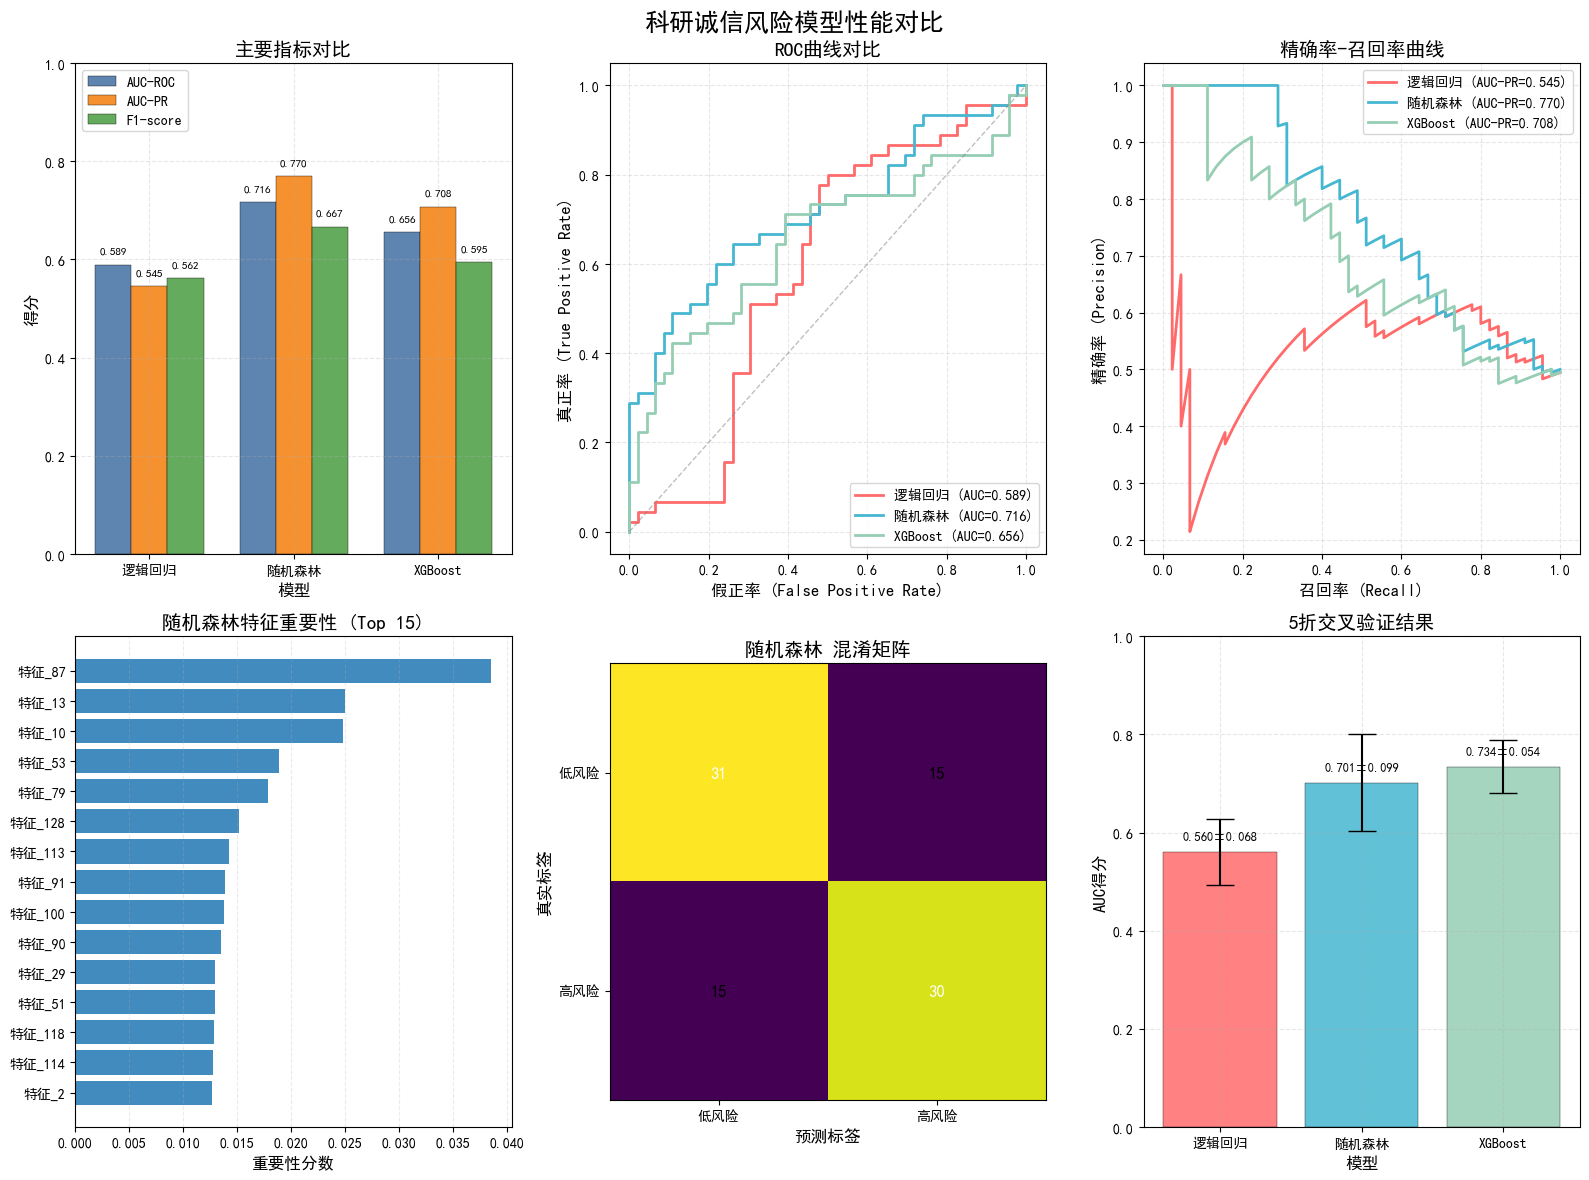


详细性能报告

📊 模型性能汇总表:
     模型  AUC-ROC   AUC-PR      精确率      召回率  F1-score
   随机森林 0.716425 0.769931 0.666667 0.666667  0.666667
XGBoost 0.655556 0.707686 0.641026 0.555556  0.595238
   逻辑回归 0.589372 0.545109 0.568182 0.555556  0.561798

📈 性能提升分析:
  随机森林 相比逻辑回归：
    AUC-ROC 提升: +21.6%
    F1-score 提升: +18.7%
  XGBoost 相比逻辑回归：
    AUC-ROC 提升: +11.2%
    F1-score 提升: +6.0%

📋 各模型详细分类报告:

▶ 逻辑回归 分类报告:
              precision    recall  f1-score   support

         低风险       0.57      0.59      0.58        46
         高风险       0.57      0.56      0.56        45

    accuracy                           0.57        91
   macro avg       0.57      0.57      0.57        91
weighted avg       0.57      0.57      0.57        91


▶ 随机森林 分类报告:
              precision    recall  f1-score   support

         低风险       0.67      0.67      0.67        46
         高风险       0.67      0.67      0.67        45

    accuracy                           0.67        91
   macro avg       0.67      0.67      0

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, 
                            recall_score, f1_score, classification_report, roc_curve, 
                            precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

class ResearchRiskModelComparison:
    def __init__(self, data_path):
        """
        初始化模型对比类
        Args:
            data_path: 实验数据.xlsx路径
        """
        self.data_path = data_path
        self.papers_df = None
        self.projects_df = None
        self.G_authors = None
        self.embeddings = None
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        
        # 定义模型字典
        self.models = {}
        self.results = {}
        
        # 不端原因严重性权重
        self.misconduct_weights = {
            '伪造、篡改图片': 6,
            '篡改图片': 3,
            '篡改数据': 3,
            '篡改数据、图片': 6,
            '编造研究过程': 4,
            '编造研究过程、不当署名': 7,
            '篡改数据、不当署名': 6,
            '伪造通讯作者邮箱': 2,
            '实验流程不规范': 2,
            '数据审核不严': 2,
            '署名不当、实验流程不规范': 5,
            '篡改数据、代写代投、伪造通讯作者邮箱、不当署名': 13,
            '篡改数据、伪造通讯作者邮箱、不当署名': 8,
            '第三方代写、伪造通讯作者邮箱': 7,
            '第三方代写代投、伪造数据': 8,
            '一稿多投': 2,
            '第三方代写代投、伪造数据、一稿多投': 10,
            '篡改数据、剽窃': 8,
            '伪造图片': 3,
            '伪造图片、不当署名': 6,
            '委托实验、不当署名': 6,
            '伪造数据': 3,
            '伪造数据、篡改图片': 6,
            '伪造数据、不当署名、伪造通讯作者邮箱等': 8,
            '伪造数据、一图多用、伪造图片、代投问题': 14,
            '伪造数据、署名不当': 6,
            '抄袭剽窃他人项目申请书内容': 6,
            '伪造通讯作者邮箱、篡改数据和图片': 8,
            '篡改数据、不当署名': 6,
            '抄袭他人基金项目申请书': 6,
            '结题报告中存在虚假信息': 5,
            '抄袭剽窃': 5,
            '造假、抄袭': 5,
            '第三方代写代投': 5,
            '署名不当': 3,
            '第三方代写代投、署名不当': 8,
            '抄袭剽窃、伪造数据': 8,
            '买卖图片数据': 3,
            '买卖数据': 3,
            '买卖论文': 5,
            '买卖论文、不当署名': 8,
            '买卖论文数据': 8,
            '买卖论文数据、不当署名': 11,
            '买卖图片数据、不当署名': 6,
            '图片不当使用、伪造数据': 6,
            '图片不当使用、数据造假、未经同意使用他人署名': 9,
            '图片不当使用、数据造假、未经同意使用他人署名、编造研究过程': 13,
            '图片造假、不当署名': 9,
            '图片造假、不当署名、伪造通讯作者邮箱等': 11,
            '买卖数据、不当署名': 6,
            '伪造论文、不当署名': 6,
            '图片不当使用、数据造假、未经同意使用他人署名': 9,
            '图片不当使用、数据造假、未经同意使用他人署名、编造研究过程': 13,
            '其他轻微不端行为': 1
        }
        
        # 责任权重映射
        self.responsibility_weights = {
            "通讯作者": 0.45,
            "第一作者": 0.35,
            "合作者": 0.20
        }
        
    def load_data(self):
        """加载实验数据"""
        print("正在加载数据...")
        try:
            self.papers_df = pd.read_excel(self.data_path, sheet_name='论文')
            self.projects_df = pd.read_excel(self.data_path, sheet_name='项目')
            print(f"论文数据加载成功，共{len(self.papers_df)}条记录")
            print(f"项目数据加载成功，共{len(self.projects_df)}条记录")
            
            # 显示数据预览
            print("\n论文数据前5行：")
            print(self.papers_df.head())
            print("\n项目数据前5行：")
            print(self.projects_df.head())
            
        except Exception as e:
            print(f"数据加载失败: {e}")
            raise
    
    def build_collaboration_network(self):
        """构建作者合作网络"""
        print("\n正在构建作者合作网络...")
        
        # 创建作者-作者网络
        self.G_authors = nx.Graph()
        
        # 处理论文中的共同作者关系（这里简化处理，实际可能需要多作者解析）
        for _, row in self.papers_df.iterrows():
            authors = [row['姓名']]
            weight = self.misconduct_weights.get(row['不端原因'], 1)
            
            # 如果实际数据中有多作者字段，需要解析
            # 这里假设每行只有一个作者，实际应用时需要根据实际情况修改
            
            # 添加作者节点和关联
            for i in range(len(authors)):
                for j in range(i + 1, len(authors)):
                    if self.G_authors.has_edge(authors[i], authors[j]):
                        self.G_authors[authors[i]][authors[j]]['weight'] += weight
                    else:
                        self.G_authors.add_edge(authors[i], authors[j], weight=weight)
        
        # 处理项目中的作者关系
        for _, row in self.projects_df.iterrows():
            author = row['姓名']
            weight = self.misconduct_weights.get(row['不端原因'], 1)
            # 项目通常只有一个负责人，暂不建立作者间连接
        
        # 研究方向相似性连接
        research_areas = self.papers_df.groupby('姓名')['研究方向'].apply(
            lambda x: ' '.join(x) if isinstance(x, str) else ' '.join(x.astype(str))
        ).reset_index()
        
        if not research_areas.empty:
            vectorizer = TfidfVectorizer()
            tfidf_matrix = vectorizer.fit_transform(research_areas['研究方向'])
            similarity_matrix = cosine_similarity(tfidf_matrix, dense_output=False)
            
            for i in range(len(research_areas)):
                for j in range(i + 1, len(research_areas)):
                    if similarity_matrix[i, j] > 0.7:
                        a1 = research_areas.iloc[i]['姓名']
                        a2 = research_areas.iloc[j]['姓名']
                        self.G_authors.add_edge(a1, a2, weight=similarity_matrix[i, j], reason='研究方向相似')
        
        # 共同机构连接
        institution_map = self.papers_df.set_index('姓名')['研究机构'].to_dict()
        for a1 in institution_map:
            for a2 in institution_map:
                if a1 != a2 and institution_map[a1] == institution_map[a2]:
                    self.G_authors.add_edge(a1, a2, weight=1, reason='研究机构相同')
        
        print(f"网络构建完成，共{self.G_authors.number_of_nodes()}个节点，{self.G_authors.number_of_edges()}条边")
        return self.G_authors
    
    # Word2Vec（Skip-gram）模型定义
    class SkipGramModel(nn.Module):
        def __init__(self, vocab_size, embedding_size):
            super().__init__()
            self.embeddings = nn.Embedding(vocab_size, embedding_size)
            self.out = nn.Linear(embedding_size, vocab_size)
        
        def forward(self, inputs):
            embeds = self.embeddings(inputs)
            outputs = self.out(embeds)
            return outputs
    
    # 数据集定义
    class SkipGramDataset(Dataset):
        def __init__(self, walks, node2id):
            self.walks = walks
            self.node2id = node2id
        
        def __len__(self):
            return len(self.walks)
        
        def __getitem__(self, idx):
            walk = self.walks[idx]
            input_ids = [self.node2id[node] for node in walk[:-1]]
            target_ids = [self.node2id[node] for node in walk[1:]]
            return torch.tensor(input_ids), torch.tensor(target_ids)
    
    def deepwalk_embedding(self, graph, walk_length=30, num_walks=100, embedding_size=64):
        """DeepWalk节点嵌入"""
        print(f"正在训练DeepWalk模型（步长={walk_length}, 重复={num_walks}, 维度={embedding_size}）...")
        
        walks = []
        nodes = list(graph.nodes())
        
        # 生成随机游走序列
        for _ in range(num_walks):
            random.shuffle(nodes)
            for node in nodes:
                walk = [str(node)]
                current = node
                for _ in range(walk_length - 1):
                    neighbors = list(graph.neighbors(current))
                    if neighbors:
                        current = random.choice(neighbors)
                        walk.append(str(current))
                    else:
                        break
                walks.append(walk)
        
        # 构建节点到ID的映射
        node2id = {node: idx for idx, node in enumerate(set([node for walk in walks for node in walk]))}
        id2node = {idx: node for node, idx in node2id.items()}
        
        # 构建数据集
        dataset = self.SkipGramDataset(walks, node2id)
        dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
        
        # 模型初始化
        model = self.SkipGramModel(len(node2id), embedding_size)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        # 训练模型
        for epoch in range(3):
            total_loss = 0
            for inputs, targets in dataloader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs.view(-1, len(node2id)), targets.view(-1))
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            print(f"Epoch {epoch+1}/3, Loss: {total_loss/len(dataloader):.4f}")
        
        # 获取嵌入
        embeddings = {}
        with torch.no_grad():
            for node, idx in node2id.items():
                embeddings[node] = model.embeddings(torch.tensor([idx])).squeeze().numpy()
        
        self.embeddings = embeddings
        print(f"嵌入学习完成，生成{len(embeddings)}个节点的嵌入向量")
        return embeddings
    
    def prepare_classification_data(self, embeddings, graph):
        """准备分类数据集"""
        print("\n正在准备分类数据集...")
        
        # 构建正样本（现有边）
        positive_samples = []
        for u, v, data in graph.edges(data=True):
            if u in embeddings and v in embeddings:
                feature_vector = np.concatenate([embeddings[u], embeddings[v]])
                positive_samples.append(feature_vector)
        
        # 构建负样本（随机非边）
        negative_samples = []
        nodes = list(graph.nodes())
        num_negative = len(positive_samples)  # 保持正负样本平衡
        
        for _ in range(num_negative):
            u, v = random.sample(nodes, 2)
            while graph.has_edge(u, v):
                u, v = random.sample(nodes, 2)
            
            if u in embeddings and v in embeddings:
                feature_vector = np.concatenate([embeddings[u], embeddings[v]])
                negative_samples.append(feature_vector)
        
        # 合并数据集
        X = np.vstack([positive_samples, negative_samples])
        y = np.array([1] * len(positive_samples) + [0] * len(negative_samples))
        
        # 随机打乱
        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices]
        
        self.X = X
        self.y = y
        print(f"数据集准备完成，正样本: {len(positive_samples)}，负样本: {len(negative_samples)}")
        return X, y
    
    def train_and_evaluate_models(self):
        """训练和评估多个模型"""
        print("\n" + "="*60)
        print("开始模型训练与性能对比")
        print("="*60)
        
        # 划分训练集和测试集
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.3, random_state=42, stratify=self.y
        )
        print(f"训练集大小: {len(self.X_train)}，测试集大小: {len(self.X_test)}")
        
        # 定义模型列表（三种模型）
        models_config = [
            {
                'name': '逻辑回归',
                'model': LogisticRegression(
                    C=1.0, 
                    max_iter=1000, 
                    random_state=42,
                    class_weight='balanced'
                ),
                'color': '#FF6B6B'  # 红色
            },
            {
                'name': '随机森林',
                'model': RandomForestClassifier(
                    n_estimators=100,
                    max_depth=10,
                    min_samples_split=5,
                    min_samples_leaf=2,
                    max_features='sqrt',
                    random_state=42,
                    class_weight='balanced',
                    n_jobs=-1
                ),
                'color': '#45B7D1'  # 蓝色
            },
            {
                'name': 'XGBoost',
                'model': XGBClassifier(
                    n_estimators=100,
                    max_depth=6,
                    learning_rate=0.1,
                    random_state=42,
                    use_label_encoder=False,
                    eval_metric='logloss',
                    scale_pos_weight=len(self.y_train[self.y_train==0])/len(self.y_train[self.y_train==1])
                ),
                'color': '#96CEB4'  # 绿色
            }
        ]
        
        # 训练和评估每个模型
        all_results = []
        
        for model_config in models_config:
            model_name = model_config['name']
            model = model_config['model']
            color = model_config['color']
            
            print(f"\n▶ 训练 {model_name} 模型...")
            
            # 训练模型
            model.fit(self.X_train, self.y_train)
            self.models[model_name] = model
            
            # 预测
            y_pred = model.predict(self.X_test)
            
            # 计算概率（用于AUC等指标）
            if hasattr(model, 'predict_proba'):
                y_prob = model.predict_proba(self.X_test)[:, 1]
            else:
                y_prob = model.decision_function(self.X_test)
                y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
            
            # 计算各项指标
            auc_roc = roc_auc_score(self.y_test, y_prob)
            auc_pr = average_precision_score(self.y_test, y_prob)
            precision = precision_score(self.y_test, y_pred)
            recall = recall_score(self.y_test, y_pred)
            f1 = f1_score(self.y_test, y_pred)
            
            # 交叉验证
            cv_scores = cross_val_score(model, self.X_train, self.y_train, 
                                       cv=5, scoring='roc_auc', n_jobs=-1)
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # 存储结果
            result = {
                '模型': model_name,
                'AUC-ROC': auc_roc,
                'AUC-PR': auc_pr,
                '精确率': precision,
                '召回率': recall,
                'F1-score': f1,
                '交叉验证均值': cv_mean,
                '交叉验证标准差': cv_std,
                '颜色': color,
                'y_pred': y_pred,
                'y_prob': y_prob
            }
            
            all_results.append(result)
            
            print(f"   AUC-ROC: {auc_roc:.3f}")
            print(f"   AUC-PR: {auc_pr:.3f}")
            print(f"   F1-score: {f1:.3f}")
            print(f"   交叉验证 (AUC): {cv_mean:.3f} ± {cv_std:.3f}")
        
        # 转换为DataFrame
        self.results_df = pd.DataFrame(all_results)
        self.results = all_results
        
        return self.results_df
    

    def visualize_comparison(self):
        """可视化模型性能对比（修正版：主要指标图颜色按“指标”区分，图例更清晰）"""
        print("\n正在生成可视化图表...")

        import numpy as np
        import matplotlib.pyplot as plt
        from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

        # 创建画布
        fig = plt.figure(figsize=(16, 12))
        fig.suptitle('科研诚信风险模型性能对比', fontsize=18, fontweight='bold')

        # =========================
        # 1) 主要指标对比柱状图（修正重点）
        # =========================
        ax1 = plt.subplot(2, 3, 1)

        metrics = ['AUC-ROC', 'AUC-PR', 'F1-score']
        metric_colors = ['#4C78A8', '#F58518', '#54A24B']  # 指标色：蓝/橙/绿（你也可换）
        bar_width = 0.25

        x = np.arange(len(self.results_df))  # 每个模型一个组
        model_names = self.results_df['模型'].tolist()

        # 画分组柱子：同一指标在不同模型上用同一种颜色
        for i, (metric, mcolor) in enumerate(zip(metrics, metric_colors)):
            values = self.results_df[metric].values
            ax1.bar(
                x + i * bar_width,
                values,
                width=bar_width,
                label=metric,          # ✅ 图例按指标
                color=mcolor,
                alpha=0.9,
                edgecolor='black',
                linewidth=0.3
            )

            # 数值标签
            for j, v in enumerate(values):
                ax1.text(
                    j + i * bar_width,
                    v + 0.02,
                    f'{v:.3f}',
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

        ax1.set_xlabel('模型', fontsize=12)
        ax1.set_ylabel('得分', fontsize=12)
        ax1.set_title('主要指标对比', fontsize=14, fontweight='bold')
        ax1.set_xticks(x + bar_width)
        ax1.set_xticklabels(model_names, rotation=0, ha='center')
        ax1.set_ylim(0, 1)
        ax1.grid(True, alpha=0.3, linestyle='--')

        # ✅ 图例现在颜色与指标一致
        ax1.legend(loc='upper left', frameon=True)

        # =========================
        # 2) ROC曲线
        # =========================
        ax2 = plt.subplot(2, 3, 2)
        for result in self.results:
            fpr, tpr, _ = roc_curve(self.y_test, result['y_prob'])
            ax2.plot(
                fpr, tpr,
                color=result['颜色'], lw=2,
                label=f"{result['模型']} (AUC={result['AUC-ROC']:.3f})"
            )
        ax2.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.5)
        ax2.set_xlabel('假正率 (False Positive Rate)', fontsize=12)
        ax2.set_ylabel('真正率 (True Positive Rate)', fontsize=12)
        ax2.set_title('ROC曲线对比', fontsize=14, fontweight='bold')
        ax2.legend(loc='lower right')
        ax2.grid(True, alpha=0.3, linestyle='--')

        # =========================
        # 3) PR曲线
        # =========================
        ax3 = plt.subplot(2, 3, 3)
        for result in self.results:
            precision, recall, _ = precision_recall_curve(self.y_test, result['y_prob'])
            ax3.plot(
                recall, precision,
                color=result['颜色'], lw=2,
                label=f"{result['模型']} (AUC-PR={result['AUC-PR']:.3f})"
            )
        ax3.set_xlabel('召回率 (Recall)', fontsize=12)
        ax3.set_ylabel('精确率 (Precision)', fontsize=12)
        ax3.set_title('精确率-召回率曲线', fontsize=14, fontweight='bold')
        ax3.legend(loc='upper right')
        ax3.grid(True, alpha=0.3, linestyle='--')

        # =========================
        # 4) 特征重要性（随机森林）
        # =========================
        ax4 = plt.subplot(2, 3, 4)
        if '随机森林' in self.models:
            rf_model = self.models['随机森林']
            if hasattr(rf_model, 'feature_importances_'):
                importances = rf_model.feature_importances_
                indices = np.argsort(importances)[-15:]  # Top 15

                ax4.barh(range(len(indices)), importances[indices], alpha=0.85)
                ax4.set_yticks(range(len(indices)))
                ax4.set_yticklabels([f'特征_{i+1}' for i in indices])
                ax4.set_xlabel('重要性分数', fontsize=12)
                ax4.set_title('随机森林特征重要性 (Top 15)', fontsize=14, fontweight='bold')
                ax4.grid(True, axis='x', alpha=0.25, linestyle='--')
            else:
                ax4.text(0.5, 0.5, '随机森林无 feature_importances_', ha='center', va='center')
                ax4.set_axis_off()
        else:
            ax4.text(0.5, 0.5, '未训练随机森林模型', ha='center', va='center')
            ax4.set_axis_off()

        # =========================
        # 5) 混淆矩阵（最佳F1模型）——用纯matplotlib替代seaborn
        # =========================
        ax5 = plt.subplot(2, 3, 5)
        best_model_idx = self.results_df['F1-score'].idxmax()
        best_model_name = self.results_df.loc[best_model_idx, '模型']
        best_model_pred = self.results[best_model_idx]['y_pred']

        cm = confusion_matrix(self.y_test, best_model_pred)
        im = ax5.imshow(cm, interpolation='nearest')
        ax5.set_title(f'{best_model_name} 混淆矩阵', fontsize=14, fontweight='bold')
        ax5.set_xlabel('预测标签', fontsize=12)
        ax5.set_ylabel('真实标签', fontsize=12)
        ax5.set_xticks([0, 1])
        ax5.set_yticks([0, 1])
        ax5.set_xticklabels(['低风险', '高风险'])
        ax5.set_yticklabels(['低风险', '高风险'])

        # 数值标注
        thresh = cm.max() / 2.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax5.text(
                    j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=12
                )

        # =========================
        # 6) 交叉验证结果
        # =========================
        ax6 = plt.subplot(2, 3, 6)

        models = self.results_df['模型']
        cv_means = self.results_df['交叉验证均值']
        cv_stds = self.results_df['交叉验证标准差']

        x_pos = np.arange(len(models))
        colors = [r['颜色'] for r in self.results]  # 这里按模型着色是合理的

        bars = ax6.bar(
            x_pos, cv_means, yerr=cv_stds, capsize=10,
            color=colors, alpha=0.85, edgecolor='black', linewidth=0.3
        )
        ax6.set_xlabel('模型', fontsize=12)
        ax6.set_ylabel('AUC得分', fontsize=12)
        ax6.set_title('5折交叉验证结果', fontsize=14, fontweight='bold')
        ax6.set_xticks(x_pos)
        ax6.set_xticklabels(models, rotation=0, ha='center')
        ax6.grid(True, alpha=0.3, linestyle='--')
        ax6.set_ylim(0, 1)

        for bar, mean, std in zip(bars, cv_means, cv_stds):
            height = bar.get_height()
            ax6.text(
                bar.get_x() + bar.get_width() / 2.,
                height + 0.02,
                f'{mean:.3f}±{std:.3f}',
                ha='center', va='bottom', fontsize=9
            )

        plt.tight_layout()
        plt.savefig('model_comparison_results_3models.png', dpi=300, bbox_inches='tight')
        plt.show()

        return fig
    
    def generate_detailed_report(self):
        """生成详细报告"""
        print("\n" + "="*60)
        print("详细性能报告")
        print("="*60)
        
        # 打印汇总表格
        print("\n📊 模型性能汇总表:")
        summary_df = self.results_df[['模型', 'AUC-ROC', 'AUC-PR', '精确率', '召回率', 'F1-score']]
        summary_df = summary_df.sort_values('F1-score', ascending=False)
        print(summary_df.to_string(index=False))
        
        # 性能提升分析
        print("\n📈 性能提升分析:")
        
        # 以逻辑回归为基线
        baseline_auc = self.results_df[self.results_df['模型'] == '逻辑回归']['AUC-ROC'].values[0]
        baseline_f1 = self.results_df[self.results_df['模型'] == '逻辑回归']['F1-score'].values[0]
        
        for _, row in self.results_df.iterrows():
            if row['模型'] != '逻辑回归':
                auc_improvement = (row['AUC-ROC'] - baseline_auc) / baseline_auc * 100
                f1_improvement = (row['F1-score'] - baseline_f1) / baseline_f1 * 100
                print(f"  {row['模型']} 相比逻辑回归：")
                print(f"    AUC-ROC 提升: {auc_improvement:+.1f}%")
                print(f"    F1-score 提升: {f1_improvement:+.1f}%")
        
        # 各模型详细分类报告
        print("\n📋 各模型详细分类报告:")
        for model_name, model in self.models.items():
            print(f"\n▶ {model_name} 分类报告:")
            y_pred = model.predict(self.X_test)
            report = classification_report(self.y_test, y_pred, target_names=['低风险', '高风险'])
            print(report)
        
        # 最佳模型分析
        best_model_idx = self.results_df['F1-score'].idxmax()
        best_model = self.results_df.loc[best_model_idx]
        
        print("\n🏆 最佳模型分析:")
        print(f"  最佳模型: {best_model['模型']}")
        print(f"  F1-score: {best_model['F1-score']:.3f}")
        print(f"  AUC-ROC: {best_model['AUC-ROC']:.3f}")
        print(f"  精确率: {best_model['精确率']:.3f}")
        print(f"  召回率: {best_model['召回率']:.3f}")
        
        # 计算模型对比的详细统计
        print("\n📊 模型对比详细统计:")
        
        # 计算性能提升
        lr_perf = self.results_df[self.results_df['模型'] == '逻辑回归'].iloc[0]
        rf_perf = self.results_df[self.results_df['模型'] == '随机森林'].iloc[0]
        xgb_perf = self.results_df[self.results_df['模型'] == 'XGBoost'].iloc[0]
        
        print(f"  1. 随机森林 vs 逻辑回归:")
        print(f"     AUC-ROC提升: {(rf_perf['AUC-ROC'] - lr_perf['AUC-ROC']) * 100:+.1f}%")
        print(f"     F1-score提升: {(rf_perf['F1-score'] - lr_perf['F1-score']) * 100:+.1f}%")
        
        print(f"  2. XGBoost vs 逻辑回归:")
        print(f"     AUC-ROC提升: {(xgb_perf['AUC-ROC'] - lr_perf['AUC-ROC']) * 100:+.1f}%")
        print(f"     F1-score提升: {(xgb_perf['F1-score'] - lr_perf['F1-score']) * 100:+.1f}%")
        
        print(f"  3. 随机森林 vs XGBoost:")
        print(f"    AUC-ROC差异: {(rf_perf['AUC-ROC'] - xgb_perf['AUC-ROC']) * 100:+.2f}%")
        print(f"    F1-score差异: {(rf_perf['F1-score'] - xgb_perf['F1-score']) * 100:+.2f}%")
        
        # 模型选择建议
        print("\n💡 模型选择建议:")
        print("  1. 如果关注整体分类性能平衡：选择F1-score最高的模型")
        print("  2. 如果更关注高风险样本识别：选择召回率最高的模型")
        print("  3. 如果要求模型可解释性：选择逻辑回归或随机森林")
        print("  4. 如果数据量很大且计算资源充足：考虑XGBoost")
        print("  5. 根据交叉验证结果，推荐使用: ", best_model['模型'])
        
        # 保存结果到文件
        output_data = {
            'results_df': self.results_df,
            'confusion_matrix': confusion_matrix(self.y_test, 
                                               self.models[best_model['模型']].predict(self.X_test))
        }
        
        # 保存详细结果
        self.results_df.to_csv('model_comparison_results_3models.csv', index=False, encoding='utf-8-sig')
        print(f"\n✅ 结果已保存到 'model_comparison_results_3models.csv'")
        
        return output_data
    
    def run_complete_comparison(self):
        """运行完整的对比流程"""
        print("科研诚信风险模型性能对比系统")
        print("="*60)
        
        # 1. 加载数据
        self.load_data()
        
        # 2. 构建网络
        self.build_collaboration_network()
        
        # 3. 节点嵌入
        self.deepwalk_embedding(self.G_authors)
        
        # 4. 准备分类数据
        self.prepare_classification_data(self.embeddings, self.G_authors)
        
        # 5. 训练和评估模型
        self.train_and_evaluate_models()
        
        # 6. 可视化
        self.visualize_comparison()
        
        # 7. 生成报告
        report_data = self.generate_detailed_report()
        
        print("\n" + "="*60)
        print("✅ 模型性能对比完成！")
        print("="*60)
        
        return report_data


# 主程序
if __name__ == "__main__":
    # 设置数据路径
    # 注意：请将路径修改为您的实际数据路径
    data_path = "实验数据.xlsx"
    
    # 创建对比器实例
    comparator = ResearchRiskModelComparison(data_path)
    
    try:
        # 运行完整对比
        results = comparator.run_complete_comparison()
        
        # 打印额外统计信息
        print("\n📊 额外统计信息:")
        print(f"  总样本数: {len(comparator.X)}")
        print(f"  正样本比例: {np.mean(comparator.y):.2%}")
        print(f"  网络节点数: {comparator.G_authors.number_of_nodes()}")
        print(f"  网络边数: {comparator.G_authors.number_of_edges()}")
        
        # 打印各模型的参数设置
        print("\n🔧 模型参数设置:")
        for model_name, model in comparator.models.items():
            print(f"\n  {model_name}:")
            if hasattr(model, 'get_params'):
                params = model.get_params()
                # 只打印部分重要参数
                if model_name == '逻辑回归':
                    print(f"    C: {params.get('C', 'N/A')}")
                    print(f"    max_iter: {params.get('max_iter', 'N/A')}")
                elif model_name == '随机森林':
                    print(f"    n_estimators: {params.get('n_estimators', 'N/A')}")
                    print(f"    max_depth: {params.get('max_depth', 'N/A')}")
                elif model_name == 'XGBoost':
                    print(f"    n_estimators: {params.get('n_estimators', 'N/A')}")
                    print(f"    max_depth: {params.get('max_depth', 'N/A')}")
                    print(f"    learning_rate: {params.get('learning_rate', 'N/A')}")
        
    except FileNotFoundError:
        print(f"错误：找不到数据文件 '{data_path}'")
        print("请确保文件路径正确，或者修改代码中的data_path变量")
    except Exception as e:
        print(f"运行过程中发生错误: {str(e)}")
        import traceback
        traceback.print_exc()